In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "dataset"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

print(TRAIN_DIR)

c:\Users\cadg0\Downloads\CSC173-DeepCV-Gumisad\dataset\train


CLAHE Function

In [3]:
def apply_clahe(image):
    """
    Apply CLAHE on the luminance channel.
    Input: RGB image
    Output: RGB image
    """

    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    merged = cv2.merge((l, a, b))

    output = cv2.cvtColor(
        merged,
        cv2.COLOR_LAB2RGB
    )

    return output

Visualize CLAHE

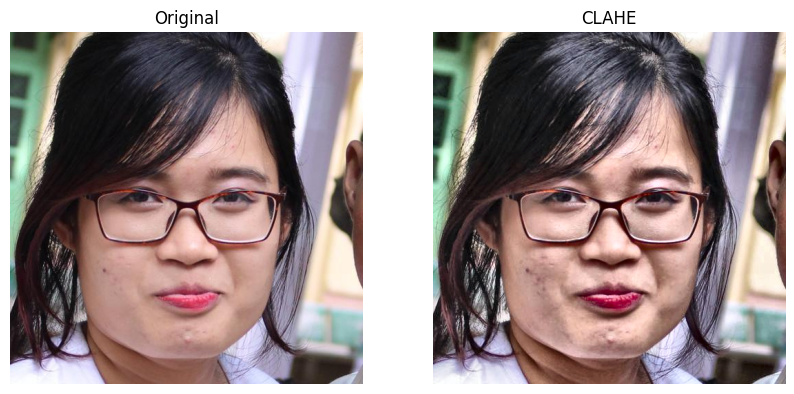

In [ ]:
import random

sample_path = random.choice(
    list((TRAIN_DIR / "imperfection").glob("*"))
)

img = cv2.imread(str(sample_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

clahe_img = apply_clahe(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clahe_img)
plt.title("CLAHE")
plt.axis("off")

plt.show()

IMAGE_SIZE = 224

Training Transform

In [6]:
train_transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Validation/Test Transform

In [7]:
val_test_transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Create Datasets

In [8]:
train_dataset = ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

In [9]:
print("Classes:", train_dataset.classes)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: ['clear', 'imperfection']
Train: 1400
Validation: 300
Test: 300


Create Dataloaders

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

Verify Batch Shapes

In [12]:
images, labels = next(iter(train_loader))

print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)

Images Shape: torch.Size([32, 3, 224, 224])
Labels Shape: torch.Size([32])


Visualize Augmented Images

In [13]:
def denormalize(img):
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img.numpy().transpose(1,2,0)

    img = std * img + mean

    img = np.clip(img, 0, 1)

    return img

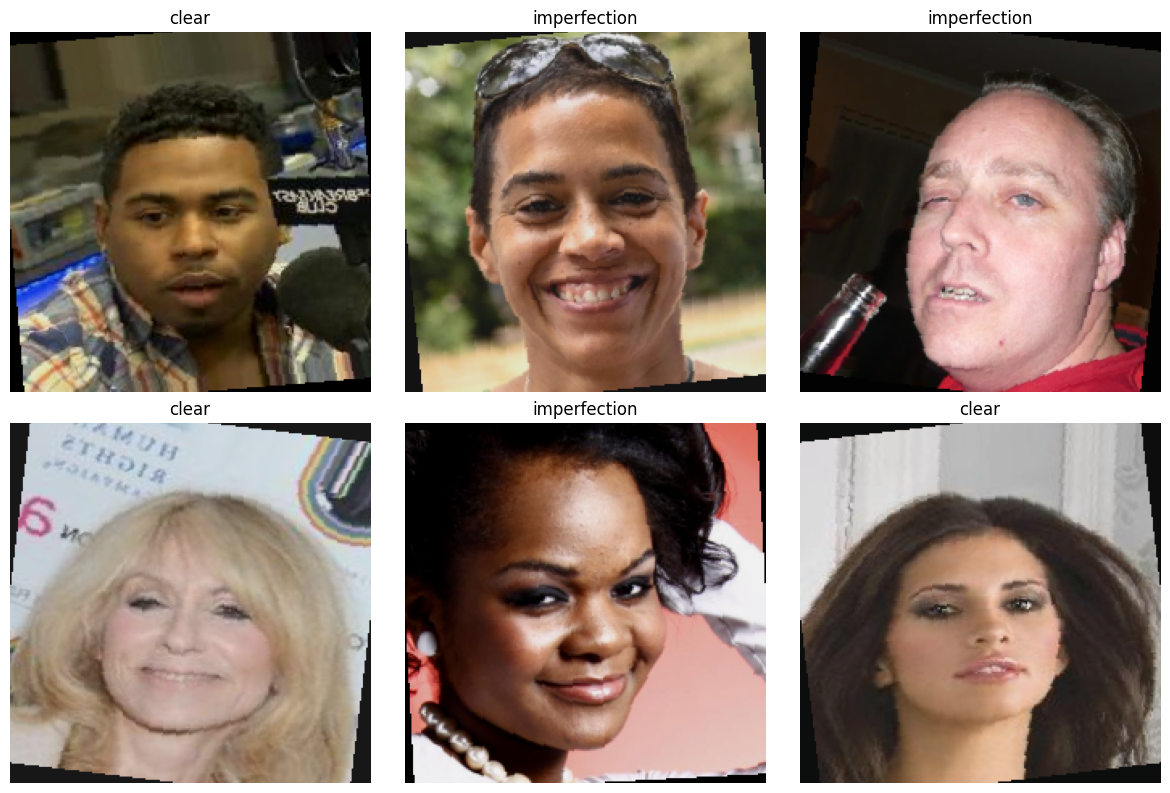

In [14]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        denormalize(images[i])
    )

    plt.title(
        train_dataset.classes[
            labels[i]
        ]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()